# 📊 IDX Exchange – EDA & Dataset Validation
### Weeks 2–3 | Data Analyst Internship
---
**Goal:** Inspect, validate, and enrich the combined residential MLS datasets before moving into cleaning and analytics.

**Steps covered in this notebook:**
1. Load datasets
2. Basic structure overview
3. Missing value analysis
4. Property type check
5. Numeric distribution review (ClosePrice, LivingArea, DaysOnMarket)
6. Mortgage rate enrichment (FRED API)
7. Save enriched datasets


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Show all columns when printing DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)


## 2. Load Datasets
Loading the combined sold and listings CSVs produced in Week 1.


In [2]:
sold     = pd.read_csv("../output/sold_combined_residential.csv", low_memory=False)
listings = pd.read_csv("../output/listings_combined_residential.csv", low_memory=False)

print("✅ Sold rows & columns:    ", sold.shape)
print("✅ Listings rows & columns:", listings.shape)


✅ Sold rows & columns:     (397603, 84)
✅ Listings rows & columns: (540183, 84)


## 3. Basic Structure Overview
Quick look at column names, data types, and the first few rows.


In [3]:
print("=== SOLD: Column Names ===")
print(sold.columns.tolist())


=== SOLD: Column Names ===
['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeD

In [4]:
print("=== SOLD: Data Types ===")
print(sold.dtypes)


=== SOLD: Data Types ===
BuyerAgentAOR                   object
ListAgentAOR                    object
Flooring                        object
ViewYN                          object
WaterfrontYN                    object
                                ...   
OriginatingSystemSubName        object
BuyerAgencyCompensationType     object
BuyerAgencyCompensation        float64
latfilled                       object
lonfilled                       object
Length: 84, dtype: object


In [5]:
sold.head(3)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,...,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,"499,000.00",551985747,jwachter@cbnorcal.com,2024-01-26,"240,000.00",Joan,Wachter,NaN,NaN,1 Baldwin Avenue 411,Residential,"1,140.00","295,000.00",777,Coldwell Banker Realty,Bay Area Senior Services,NaN,Joan Wachter,...,NaN,NaN,CA,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,False,1.00,Other,94401,"6,472.00",NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,"759,900.00",522107581,mdarwich12@gmail.com,2024-01-05,"815,000.00",Michael,Darwich,NaN,NaN,2811 C Avenue,Residential,"1,974.00","759,900.00",33,Berkshire Hathaway HomeServices California Pro...,FOSTER HAMILTON Real Estate,NaN,Michael Darwich,...,NaN,NaN,CA,NaN,NaN,False,2.00,NaN,Two,NaN,NaN,NaN,False,2.00,NaN,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,"739,900.00",510919001,mdarwich12@gmail.com,2024-01-05,"810,000.00",Michael,Darwich,NaN,NaN,2812 C Avenue,Residential,"1,974.00","770,000.00",228,Berkshire Hathaway HomeServices California Pro...,FOSTER HAMILTON Real Estate,NaN,Michael Darwich,...,NaN,NaN,CA,NaN,NaN,False,2.00,NaN,Two,NaN,NaN,NaN,False,2.00,NaN,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN


## 4. Missing Value Analysis
Per the handbook: calculate missing counts and percentages, and flag any columns above **90% null**.


In [6]:
missing_count   = sold.isnull().sum()
missing_pct     = (missing_count / len(sold)) * 100

missing_df = pd.DataFrame({
    "missing_count":   missing_count,
    "missing_percent": missing_pct
}).sort_values("missing_percent", ascending=False)

print("=== Top 20 columns with most missing values ===")
missing_df.head(20)


=== Top 20 columns with most missing values ===


,missing_count,missing_percent
CoveredSpaces,397603,100.00
MiddleOrJuniorSchoolDistrict,397603,100.00
AboveGradeFinishedArea,397603,100.00
FireplacesTotal,397603,100.00
TaxYear,397603,100.00
ElementarySchoolDistrict,397603,100.00
BusinessType,397603,100.00
TaxAnnualAmount,397603,100.00
WaterfrontYN,397355,99.94
BelowGradeFinishedArea,395313,99.42


In [7]:
# Flag columns above 90% missing — candidates to drop
high_missing = missing_df[missing_df["missing_percent"] > 90]

print(f"⚠️  Columns above 90% missing: {len(high_missing)}")
high_missing


⚠️  Columns above 90% missing: 17


,missing_count,missing_percent
CoveredSpaces,397603,100.00
MiddleOrJuniorSchoolDistrict,397603,100.00
AboveGradeFinishedArea,397603,100.00
FireplacesTotal,397603,100.00
TaxYear,397603,100.00
ElementarySchoolDistrict,397603,100.00
BusinessType,397603,100.00
TaxAnnualAmount,397603,100.00
WaterfrontYN,397355,99.94
BelowGradeFinishedArea,395313,99.42


## 5. Property Type Check
Verify the dataset is filtered to Residential only (done in Week 1, confirming here).


In [8]:
print("=== PropertyType value counts ===")
print(sold["PropertyType"].value_counts())


=== PropertyType value counts ===
PropertyType
Residential    397603
Name: count, dtype: int64


## 6. Numeric Distribution Review
Handbook fields to analyze: **ClosePrice**, **LivingArea**, **DaysOnMarket**.

For each: descriptive stats + histogram + boxplot.


### 6.1 `ClosePrice`

In [9]:
print("=== ClosePrice – Descriptive Stats ===")
print(sold["ClosePrice"].describe(percentiles=[.1, .25, .5, .75, .9]))


=== ClosePrice – Descriptive Stats ===
count       397,601.00
mean      1,185,616.36
std       5,922,380.41
min               0.00
10%         415,000.00
25%         575,000.00
50%         820,000.00
75%       1,300,000.00
90%       2,058,600.00
max     989,500,000.00
Name: ClosePrice, dtype: float64


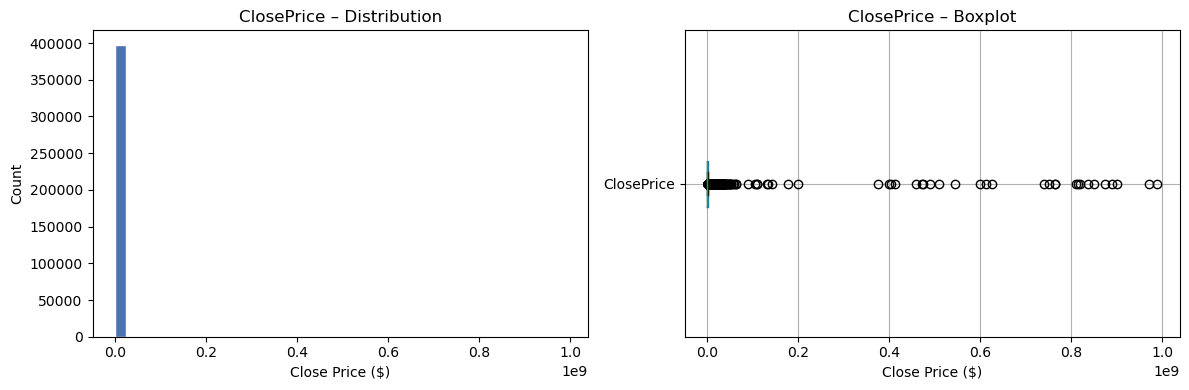

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
sold["ClosePrice"].dropna().plot(kind="hist", bins=40, ax=ax1, color="#4C72B0", edgecolor="white")
ax1.set_title("ClosePrice – Distribution")
ax1.set_xlabel("Close Price ($)")
ax1.set_ylabel("Count")

# Boxplot
sold.boxplot(column="ClosePrice", ax=ax2, vert=False)
ax2.set_title("ClosePrice – Boxplot")
ax2.set_xlabel("Close Price ($)")

plt.tight_layout()
plt.show()


### 6.2 `LivingArea`

In [11]:
print("=== LivingArea – Descriptive Stats ===")
print(sold["LivingArea"].describe(percentiles=[.1, .25, .5, .75, .9]))


=== LivingArea – Descriptive Stats ===
count      397,374.00
mean         1,904.35
std         27,017.81
min              0.00
10%            982.00
25%          1,247.00
50%          1,641.00
75%          2,217.00
90%          2,975.00
max     17,021,321.00
Name: LivingArea, dtype: float64


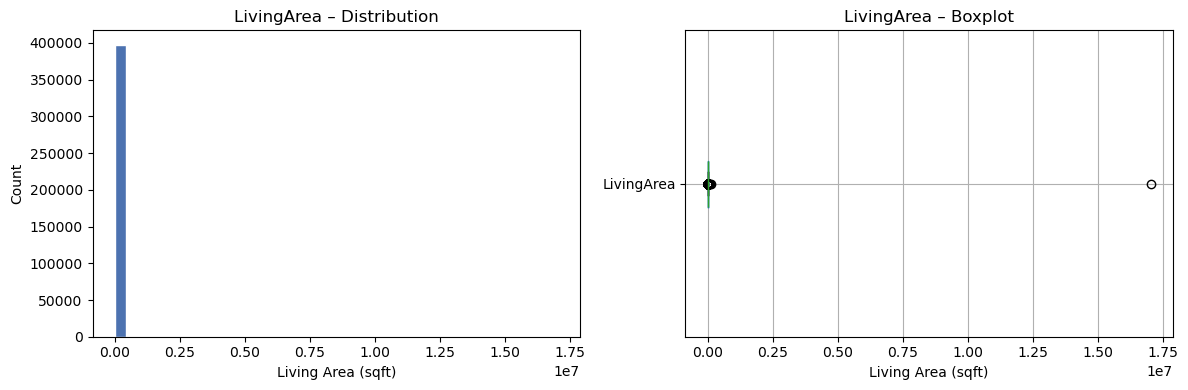

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
sold["LivingArea"].dropna().plot(kind="hist", bins=40, ax=ax1, color="#4C72B0", edgecolor="white")
ax1.set_title("LivingArea – Distribution")
ax1.set_xlabel("Living Area (sqft)")
ax1.set_ylabel("Count")

# Boxplot
sold.boxplot(column="LivingArea", ax=ax2, vert=False)
ax2.set_title("LivingArea – Boxplot")
ax2.set_xlabel("Living Area (sqft)")

plt.tight_layout()
plt.show()


### 6.3 `DaysOnMarket`

In [13]:
print("=== DaysOnMarket – Descriptive Stats ===")
print(sold["DaysOnMarket"].describe(percentiles=[.1, .25, .5, .75, .9]))


=== DaysOnMarket – Descriptive Stats ===
count   397,603.00
mean         37.34
std          53.54
min        -288.00
10%           4.00
25%           8.00
50%          19.00
75%          48.00
90%          94.00
max      12,430.00
Name: DaysOnMarket, dtype: float64


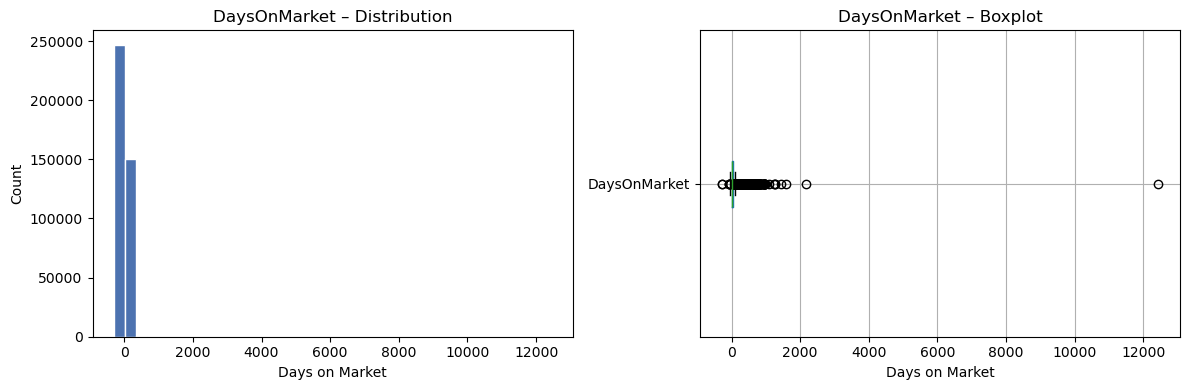

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
sold["DaysOnMarket"].dropna().plot(kind="hist", bins=40, ax=ax1, color="#4C72B0", edgecolor="white")
ax1.set_title("DaysOnMarket – Distribution")
ax1.set_xlabel("Days on Market")
ax1.set_ylabel("Count")

# Boxplot
sold.boxplot(column="DaysOnMarket", ax=ax2, vert=False)
ax2.set_title("DaysOnMarket – Boxplot")
ax2.set_xlabel("Days on Market")

plt.tight_layout()
plt.show()


## 7. Mortgage Rate Enrichment (FRED API)
Fetch the 30-year fixed mortgage rate from FRED, resample to monthly averages, and merge onto both datasets.

> No API key needed — FRED provides a public CSV endpoint.


In [15]:
# Step 1 – Fetch weekly mortgage rate data from FRED
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=["observation_date"])
mortgage.columns = ["date", "rate_30yr_fixed"]

print("✅ Mortgage data fetched:", mortgage.shape)
mortgage.tail(5)


✅ Mortgage data fetched: (2874, 2)


,date,rate_30yr_fixed
2869,2026-03-26,6.38
2870,2026-04-02,6.46
2871,2026-04-09,6.37
2872,2026-04-16,6.30
2873,2026-04-23,6.23


In [16]:
# Step 2 – Resample from weekly → monthly average
mortgage["year_month"] = mortgage["date"].dt.to_period("M")

mortgage_monthly = (
    mortgage
    .groupby("year_month")["rate_30yr_fixed"]
    .mean()
    .reset_index()
)

print("✅ Monthly averages computed:", mortgage_monthly.shape)
mortgage_monthly.tail(5)


✅ Monthly averages computed: (661, 2)


,year_month,rate_30yr_fixed
656,2025-12,6.19
657,2026-01,6.10
658,2026-02,6.05
659,2026-03,6.18
660,2026-04,6.34


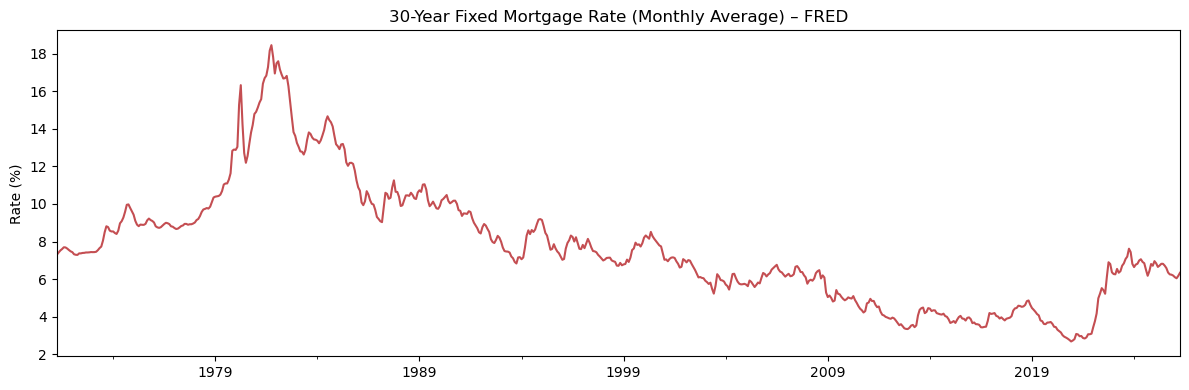

In [17]:
# Quick plot of mortgage rates over time
fig, ax = plt.subplots(figsize=(12, 4))
mortgage_monthly.set_index("year_month").plot(ax=ax, color="#C44E52", legend=False)
ax.set_title("30-Year Fixed Mortgage Rate (Monthly Average) – FRED")
ax.set_ylabel("Rate (%)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


In [18]:
# Step 3 – Create year_month key on MLS datasets
sold["year_month"]     = pd.to_datetime(sold["CloseDate"]).dt.to_period("M")
listings["year_month"] = pd.to_datetime(listings["ListingContractDate"]).dt.to_period("M")


In [19]:
# Step 4 – Merge mortgage rates onto both datasets
sold     = sold.merge(mortgage_monthly,     on="year_month", how="left")
listings = listings.merge(mortgage_monthly, on="year_month", how="left")


In [20]:
# Step 5 – Validate: null rate count should be 0 (or very low for edge dates)
print("Sold – null rates:    ", sold["rate_30yr_fixed"].isnull().sum())
print("Listings – null rates:", listings["rate_30yr_fixed"].isnull().sum())

sold[["CloseDate", "year_month", "ClosePrice", "rate_30yr_fixed"]].head(5)


Sold – null rates:     0
Listings – null rates: 0


,CloseDate,year_month,ClosePrice,rate_30yr_fixed
0,2024-01-26,2024-01,"240,000.00",6.64
1,2024-01-05,2024-01,"815,000.00",6.64
2,2024-01-05,2024-01,"810,000.00",6.64
3,2024-01-30,2024-01,"858,000.00",6.64
4,2024-01-29,2024-01,"1,890,500.00",6.64


## 8. Save Enriched Datasets
Save both datasets with the mortgage rate column attached.


In [21]:
sold.to_csv("../output/sold_with_rates.csv", index=False)
listings.to_csv("../output/listings_with_rates.csv", index=False)

print("✅ Saved: sold_with_rates.csv")
print("✅ Saved: listings_with_rates.csv")
print(f"   Sold final shape:     {sold.shape}")
print(f"   Listings final shape: {listings.shape}")


✅ Saved: sold_with_rates.csv
✅ Saved: listings_with_rates.csv
   Sold final shape:     (397603, 86)
   Listings final shape: (540183, 86)


---
## ✅ Weeks 2–3 Complete

**What was done:**
- Loaded combined Residential MLS datasets
- Reviewed structure (columns, dtypes, sample rows)
- Identified missing values and flagged columns >90% null
- Confirmed PropertyType == Residential filter
- Analyzed distributions of ClosePrice, LivingArea, DaysOnMarket
- Fetched 30-yr mortgage rate from FRED and merged onto both datasets
- Saved enriched outputs: `sold_with_rates.csv` and `listings_with_rates.csv`

**Next → Weeks 4–5:** Data Cleaning & Preparation (date fields, invalid values, geographic checks)
